# Segmentation client par K-means

Ce notebook compare deux segmentations construites à partir du fichier complet produit par le notebook précédent :

- **Approche valide** : `recence_jours_scaled`, `frequence_scaled`, `montant_total_scaled` ;
- **Approche globale** : `recence_globale_jours_scaled`, `frequence_globale_scaled`, `montant_global_scaled`.

Pour chaque approche, plusieurs valeurs de `k` sont testées avec la méthode du coude et le score de silhouette. Le choix final de `k` est laissé à l'interprétation des graphiques.

In [8]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
import src.clustering as clustering

importlib.reload(clustering)
from src.clustering import (
    GLOBAL_SCALED_COLUMNS,
    VALID_SCALED_COLUMNS,
    evaluate_k_values,
    run_segmentation,
)

FIGURES_DIR = Path("../figures")
OUTPUT_DIR = Path("../outputs")
FIGURES_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

## 1. Chargement des caractéristiques

Le fichier contient une ligne par client, les RFM bruts, leurs transformations et les variables descriptives. K-means est entraîné uniquement sur les colonnes standardisées.

In [2]:
input_path = Path("../data/processed/features_rfm_datacsv")
data = pd.read_csv(input_path)

required_columns = {"CustomerID", "pays_residence", "produit_top_code", "produit_top_description"}
required_columns.update(VALID_SCALED_COLUMNS + GLOBAL_SCALED_COLUMNS)
missing_columns = required_columns.difference(data.columns)
if missing_columns:
    raise ValueError(f"Colonnes manquantes : {sorted(missing_columns)}")

print(f"Clients chargés : {len(data):,}")
data.head()

Clients chargés : 5,856


,CustomerID,recence_jours,frequence,montant_total,recence_globale_jours,frequence_globale,montant_global,pays_residence,nb_produits_distincts,nb_annulations,...,montant_total_log,recence_jours_scaled,frequence_scaled,montant_total_scaled,recence_globale_jours_log,frequence_globale_log,montant_global_log,recence_globale_jours_scaled,frequence_globale_scaled,montant_global_scaled
0,12346,326,12,"77,556.460",326,14,368.360,United Kingdom,25,2,...,11.259,0.860,1.260,3.222,5.790,2.708,5.912,0.869,1.219,-0.587
1,12347,2,8,"4,921.530",2,8,"4,921.530",Iceland,119,0,...,8.502,-2.150,0.805,1.226,1.099,2.197,8.502,-2.095,0.626,1.200
2,12348,75,5,"1,658.400",75,5,"1,658.400",Finland,24,0,...,7.414,-0.076,0.303,0.439,4.331,1.792,7.414,-0.053,0.155,0.450
3,12349,19,3,"3,678.690",19,4,"3,654.540",Italy,136,5,...,8.211,-0.933,-0.199,1.015,2.996,1.609,8.204,-0.896,-0.057,0.995
4,12350,310,1,294.400,310,1,294.400,Norway,16,0,...,5.688,0.828,-1.057,-0.811,5.740,0.693,5.688,0.837,-1.120,-0.741


## 2. Évaluation des valeurs de k

Le coude mesure la baisse de l'inertie quand `k` augmente. Le score de silhouette mesure la cohésion des segments et leur séparation ; plus il est élevé, meilleure est la séparation. Le score est calculé pour `k >= 2`.

In [4]:
k_values = range(2, 11)

results_valid = evaluate_k_values(data, VALID_SCALED_COLUMNS, k_values)
results_global = evaluate_k_values(data, GLOBAL_SCALED_COLUMNS, k_values)

results_valid["approche"] = "Achats valides"
results_global["approche"] = "RFM global"
results = pd.concat([results_valid, results_global], ignore_index=True)

results

,k,inertie,silhouette,approche
0,2,"8,566.897",0.438,Achats valides
1,3,"6,339.141",0.347,Achats valides
2,4,"4,910.922",0.365,Achats valides
3,5,"4,093.209",0.343,Achats valides
4,6,"3,551.390",0.336,Achats valides
5,7,"3,188.881",0.297,Achats valides
6,8,"2,899.735",0.307,Achats valides
7,9,"2,650.646",0.288,Achats valides
8,10,"2,460.066",0.288,Achats valides
9,2,"8,783.797",0.432,RFM global


## 3. Graphiques de comparaison

Les deux approches sont affichées dans une même figure pour faciliter la comparaison. Le coude ne suffit pas à lui seul : le choix de `k` doit aussi tenir compte du score de silhouette et de l'interprétabilité métier.

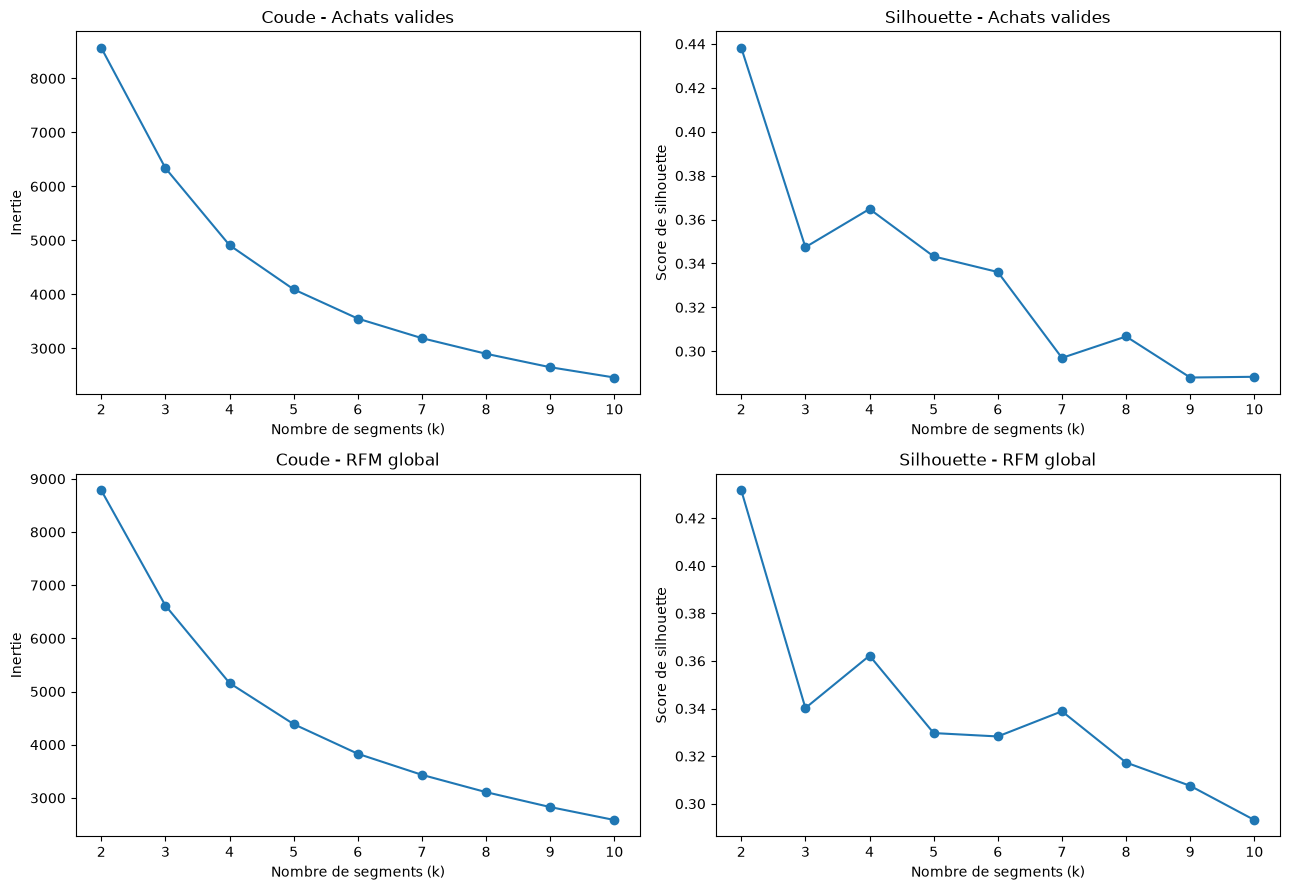

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, (label, approach_results) in enumerate(
    [("Achats valides", results_valid), ("RFM global", results_global)]
):
    axes[row, 0].plot(approach_results["k"], approach_results["inertie"], marker="o")
    axes[row, 0].set_title(f"Coude - {label}")
    axes[row, 0].set_xlabel("Nombre de segments (k)")
    axes[row, 0].set_ylabel("Inertie")

    axes[row, 1].plot(approach_results["k"], approach_results["silhouette"], marker="o")
    axes[row, 1].set_title(f"Silhouette - {label}")
    axes[row, 1].set_xlabel("Nombre de segments (k)")
    axes[row, 1].set_ylabel("Score de silhouette")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "evaluation_k_deux_approches.png", dpi=150)
plt.show()

## 4. Aide à la décision

Le meilleur score de silhouette est un repère statistique, pas une décision automatique. On vérifie aussi le coude et la lisibilité des profils avant de fixer les valeurs finales de `k`.

In [6]:
best_k = results.loc[results.groupby("approche")["silhouette"].idxmax()]
print("Meilleur score de silhouette observé pour chaque approche :")
best_k[["approche", "k", "silhouette", "inertie"]]

Meilleur score de silhouette observé pour chaque approche :


,approche,k,silhouette,inertie
0,Achats valides,2,0.438,"8,566.897"
9,RFM global,2,0.432,"8,783.797"


In [9]:
k_valid_final = 4
k_global_final = 4

summaries = run_segmentation(
    input_path=input_path,
    output_dir=OUTPUT_DIR,
    k_valid=k_valid_final,
    k_global=k_global_final,
)

for approach, summary in summaries.items():
    print(f"\nRésumé des segments - {approach}")
    display(summary)


Résumé des segments - valid


,segment,effectif,chiffre_affaires_segment,recence_moyenne,frequence_moyenne,montant_moyen,top_pays,top_produit_code,top_produit_description,top_produits,part_chiffre_affaires_pct
0,0,1970,316.871,393.017,1.379,316.871,United Kingdom,21212,WORLD WAR 2 GLIDERS ASSTD DESIGNS,"WORLD WAR 2 GLIDERS ASSTD DESIGNS, ASSTD DESIG...",3.652
1,1,1249,847.738,28.259,3.026,847.738,United Kingdom,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,"WORLD WAR 2 GLIDERS ASSTD DESIGNS, MINI PAINT ...",6.194
2,2,1186,"10,645.252",28.023,19.186,"10,645.252",United Kingdom,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,"WORLD WAR 2 GLIDERS ASSTD DESIGNS, ASSORTED CO...",73.854
3,3,1451,"1,920.437",227.862,5.077,"1,920.437",United Kingdom,85123,WHITE HANGING HEART T-LIGHT HOLDER,"WHITE HANGING HEART T-LIGHT HOLDER, WORLD WAR ...",16.301



Résumé des segments - global


,segment,effectif,chiffre_affaires_segment,recence_moyenne,frequence_moyenne,montant_moyen,top_pays,top_produit_code,top_produit_description,top_produits,part_chiffre_affaires_pct
0,0,2018,323.590,387.936,1.568,323.590,United Kingdom,21212,WORLD WAR 2 GLIDERS ASSTD DESIGNS,"WORLD WAR 2 GLIDERS ASSTD DESIGNS, ASSTD DESIG...",3.985
1,1,1481,"1,956.647",213.471,6.485,"1,956.647",United Kingdom,85123,WHITE HANGING HEART T-LIGHT HOLDER,"WHITE HANGING HEART T-LIGHT HOLDER, WORLD WAR ...",17.685
2,2,1256,863.806,26.347,3.490,863.806,United Kingdom,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,"WORLD WAR 2 GLIDERS ASSTD DESIGNS, MINI PAINT ...",6.621
3,3,1101,"10,672.387",24.348,24.280,"10,672.387",United Kingdom,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,"WORLD WAR 2 GLIDERS ASSTD DESIGNS, WHITE HANGI...",71.709


## Fichiers produits

Le script réutilisable se trouve dans `src/clustering.py`. Il peut être relancé après modification des valeurs de `k`.

Pour chaque approche, il produit :

- `clients_segmentes_valid.csv` ou `clients_segmentes_global.csv` ;
- `resume_segments_valid.csv` ou `resume_segments_global.csv`.

Le résumé contient l'effectif, la part du chiffre d'affaires total, les moyennes RFM, le pays dominant et le produit dominant de chaque segment.